Load the Data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('D:/kifiya AI/financial-news-sentiment/data/raw_analyst_ratings.csv') 

# Convert date column to datetime objects immediately
df['date'] = pd.to_datetime(df['date'], format='ISO8601')


print(df.head())
print(df.info())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                       date stock  
0 2020-06-05 10:30:54-04:00     A  
1 2020-06-03 10:45:20-04:00     A  
2 2020-05-26 04:30:07-04:00     

Descriptive Statistics

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


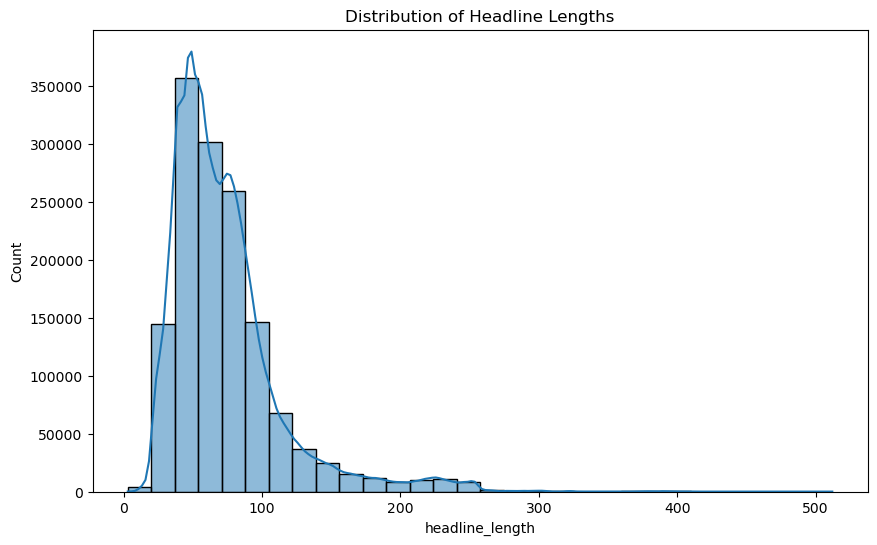

Top 10 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [5]:
# 1. Headline Length Analysis
df['headline_length'] = df['headline'].apply(len)
print(df['headline_length'].describe())

# Ploting histogram of headline lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_length'], bins=30, kde=True)
plt.title('Distribution of Headline Lengths')
plt.show()

# 2. Article Counts per Publisher
publisher_counts = df['publisher'].value_counts()
print("Top 10 Publishers:")
print(publisher_counts.head(10))

Text Analysis

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


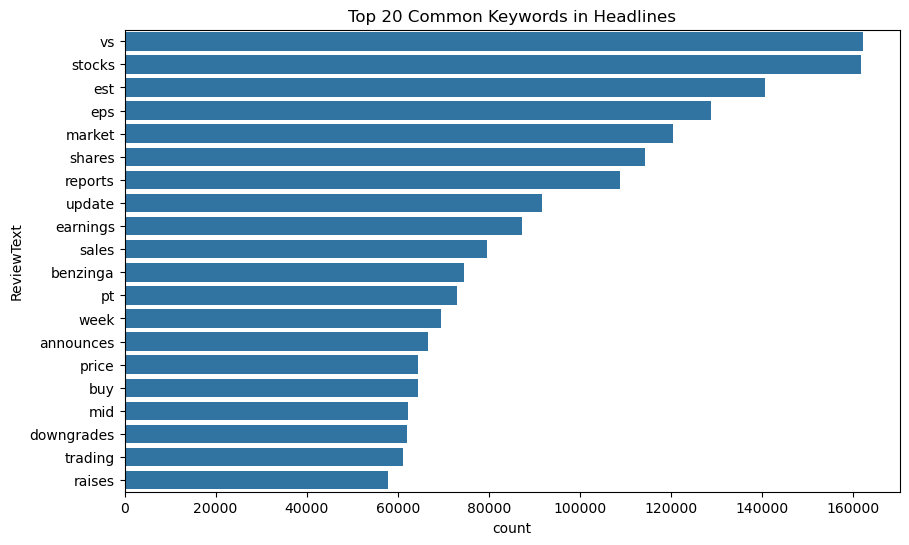

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_top_n_words(corpus, n=None):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# to get top 20 keywords from headlines
common_words = get_top_n_words(df['headline'], 20)
df_common = pd.DataFrame(common_words, columns=['ReviewText', 'count'])

# Plot the top keywords
plt.figure(figsize=(10, 6))
sns.barplot(data=df_common, x='count', y='ReviewText')
plt.title('Top 20 Common Keywords in Headlines')
plt.show()

Time Series Analysis

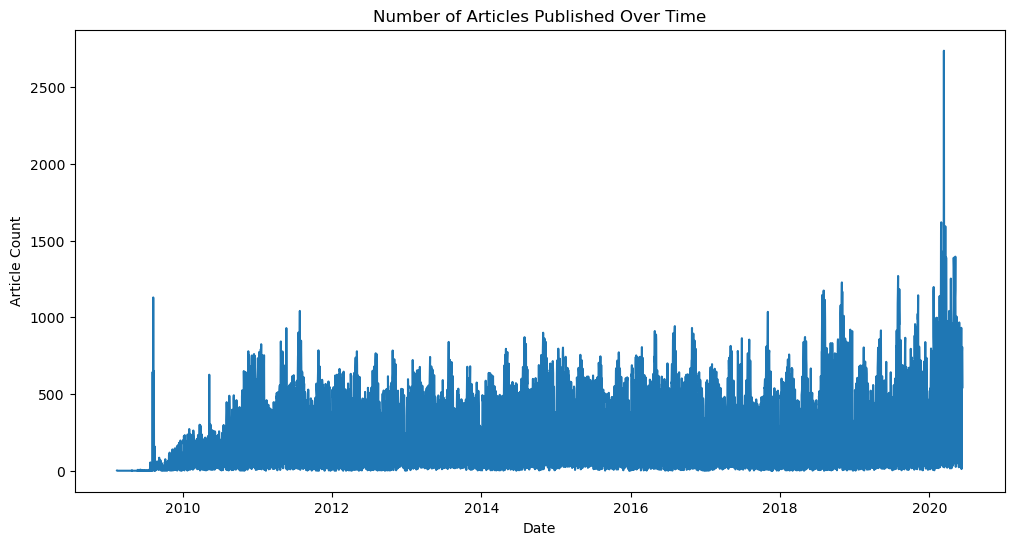

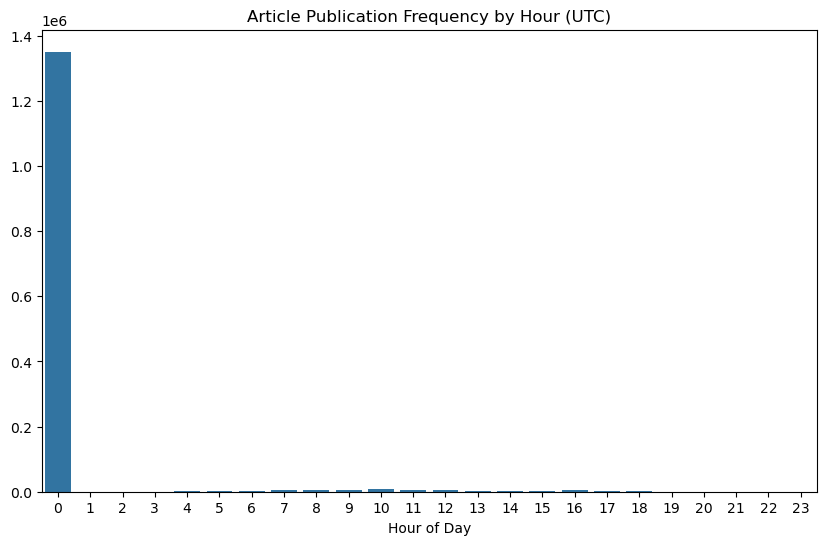

In [7]:
# 1. Trends over time (Daily frequency)
daily_counts = df.resample('D', on='date').count()

plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts['headline'])
plt.title('Number of Articles Published Over Time')
plt.xlabel('Date')
plt.ylabel('Article Count')
plt.show()

# 2. Analysis of Publishing Times (Hour of day)
df['hour'] = df['date'].dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title('Article Publication Frequency by Hour (UTC)')
plt.xlabel('Hour of Day')
plt.show()

Publisher Analysis

Top Publisher Domains:
publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


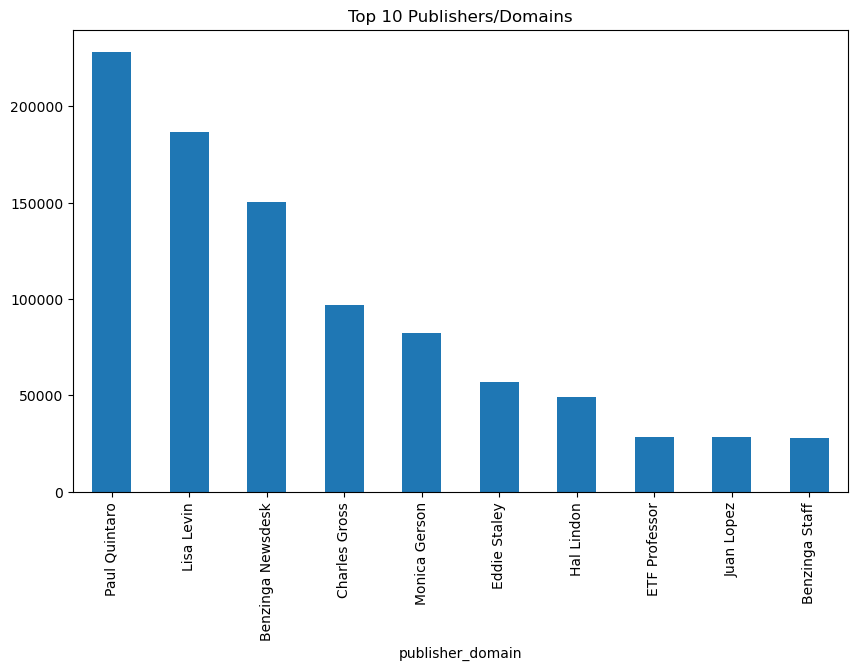

In [8]:
# Check if publishers look like emails (contain '@')
df['publisher_domain'] = df['publisher'].apply(lambda x: x.split('@')[1] if '@' in str(x) else x)

# Count unique domains
domain_counts = df['publisher_domain'].value_counts()
print("Top Publisher Domains:")
print(domain_counts.head(10))

# Visualize top publishers
plt.figure(figsize=(10, 6))
domain_counts.head(10).plot(kind='bar')
plt.title('Top 10 Publishers/Domains')
plt.show()